In [1]:
import sys
import os 
from pathlib import Path
try:
    current_path = Path.cwd()
    if current_path.name == 'notebook' and current_path.parent.name == 'research':
        project_root = current_path.parent.parent
    else:
        project_root = current_path

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    print(f" Project root terdeteksi: {project_root}")

except Exception as e:
    print(f" Gagal mendeteksi root. periksa struktur directory/folder/. Error: {e}")

 Project root terdeteksi: /home/bumip/orca


In [1]:
import sys
import os 
from pathlib import Path
try:
    current_path = Path.cwd()
    if current_path.name == 'notebook' and current_path.parent.name == 'research':
        project_root = current_path.parent.parent
    else:
        project_root = current_path

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    print(f" Project root terdeteksi: {project_root}")

except Exception as e:
    print(f" Gagal mendeteksi root. periksa struktur directory/folder/. Error: {e}")

 Project root terdeteksi: /home/bumip/orca


In [2]:
import os 
import sys
import time
from datetime import datetime
from typing import List, Dict, Any

# Third-party Lib (Data & Viz)
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import pandas as pd
"""
Local/Custom Core Engine (Black-box Layer)
Memastikan root project masuk ke sys.path jika dijalankan dari sub-folder
"""
sys.path.append(os.path.abspath(os.path.join('..')))

try:
    from core.signals import MarketObservation, SignalConfig
    from core.signals.strategies import KalmanMeanReversion
    from core.math.kalman import KalmanConfig, AdaptationMode
    CORE_LOADED = True
    print("Module core load success")

except ImportError as e:
    CORE_LOADED = False
    print(f"Warning: Core component failed to load: {e}")

# Agar tidak ada warning menggangu saat experiment
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f"🚀 Environment Initialized at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



[FACTORY] 1. Starting Import Sequence...
[FACTORY] ✅ Import SUCCESS: <class 'core.signals.strategies.kalman_mr.KalmanMeanReversion'>

[SYSTEM] ⚡ Force-Registering Strategies...
[SYSTEM] ✅ Strategy Registration Complete.

Module core load success
🚀 Environment Initialized at: 2026-03-04 15:20:55


In [3]:
# ============================================================================
# RESEARCH & LAB VISUAL CONFIGURATION
# ============================================================================
def apply_lab_style():
    """ Mengatur estetika plot untuk kebutuhan publikasi/riset quant."""
    sns.set_theme(style="darkgrid", palette="muted")

    custom_params={
        'figure.figsize': (14, 7),
        'figure.dpi': 120,
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 13,
        'lines.linewidth': 1.8,
        'legend.frameon': True,
        'savefig.bbox': 'tight',
        'savefig.dpi': 300  # High res untuk simpan gambar
    }

apply_lab_style()

In [4]:
# ============================================================================
# SYSTEM AUDIT (Explicit Version Check)
# ============================================================================
libraries = {
    "polars":  pl.__version__,
    "NumPy": np.__version__,
    "Matplotlib": plt.matplotlib.__version__,
    "Seaborn": sns.__version__,
    "Python": sys.version.split()[0]
}
print("Lab Ready, Lib Audit:")
print("-" * 30)
for lib, version in libraries.items():
    print(f"{lib:<12} : v{version}")
print("-" * 30)
print(f"Core Engine Status: {'Loaded' if CORE_LOADED else 'Failed'}")

Lab Ready, Lib Audit:
------------------------------
polars       : v1.38.1
NumPy        : v2.4.2
Matplotlib   : v3.10.8
Seaborn      : v0.13.2
Python       : v3.11.14
------------------------------
Core Engine Status: Loaded


In [5]:
# ============================================================================
# RESEARCH & LAB VISUAL CONFIGURATION
# ============================================================================
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['savefig.dpi'] = 120

# ============================================================================
# Verifikasi versi
# ============================================================================
print("\n Lab Ready. Versi pustaka/Lib:")
print(f" Polars      :{pl.__version__}")
print(f" NumPy       :{np.__version__}")
print(f" Matplotlib  :{plt.matplotlib.__version__}")
print(f" Seaborn     :{sns.__version__}")


 Lab Ready. Versi pustaka/Lib:
 Polars      :1.38.1
 NumPy       :2.4.2
 Matplotlib  :3.10.8
 Seaborn     :0.13.2


In [7]:
silver_lake_directory_path: str = "/home/bumip/orca/data/silver/"

lazy_september_data_query = (
    pl.scan_parquet(silver_lake_directory_path + "**/*.parquet", hive_partitioning=True)
    .filter(pl.col("year") == "2025", pl.col("month") == "09")
    .select(["timestamp", "close_DOGE", "close_BTC"])
)
raw_price_pandas_dataframe: pd.DataFrame = lazy_september_data_query.collect().to_pandas()
raw = raw_price_pandas_dataframe

if pd.api.types.is_datetime64_any_dtype(raw["timestamp"]):
    raw["timestamp"] = (
        raw["timestamp"].astype("int64") // 1_000_000
    )
else:
    raw["timestamp"] = raw["timestamp"].astype("int64")
assert len(raw) > 0, " Data is empty! No rows loaded."

raw = raw.dropna()
raw = raw.sort_values(by="timestamp").reset_index(drop=True)

number_of_rows = len(raw)
print(f"SEPTEMBER 2025 DATA READY: Successfully loaded {number_of_rows} rows from Silver Lake.")

SEPTEMBER 2025 DATA READY: Successfully loaded 43200 rows from Silver Lake.


In [12]:
# CELL 2: Full Engine Run (Baseline Execution)

# 1. Explicit configuration with verbose naming
baseline_september_config: SignalConfig = SignalConfig(
    name="Baseline",
    entry_z_score=2.0,
    exit_z_score=0.5,
    stop_loss_z=4.0,
    volatility_window=50
    # warmup_ticks defaults to 100, max_position to 1.0, hedge_ratio to 1.0, version to "1.0.0"
)

# 2. Assemble the Kalman engine (composition)
baseline_kalman_engine: KalmanMeanReversion = KalmanMeanReversion(signal_config=baseline_september_config)

# 3. Execute on full dataset (functional monadic run)
execution_result = baseline_kalman_engine.generate_signals(df=raw_price_pandas_dataframe)

# 4. Safe unpacking with guard clause
if execution_result.is_ok():
    clean_signal_dataframe: pd.DataFrame = execution_result.unwrap()
    row_count = len(clean_signal_dataframe)
    print(f"🟢 ENGINE RUN SUCCESSFUL: {row_count} rows processed without errors!")
else:
    error_message = execution_result.unwrap_err()
    print(f"🔴 ENGINE FAILED: {error_message}")
    # Fallback empty DataFrame to avoid NameError downstream
    clean_signal_dataframe = pd.DataFrame()

🟢 ENGINE RUN SUCCESSFUL: 43200 rows processed without errors!


In [13]:
# CELL 3: Data Sanity Check

# 1. Count input rows (from Cell 1 raw data)
total_input_rows: int = len(raw_price_pandas_dataframe)

# 2. Count output rows (from Cell 2 clean signal data)
total_output_rows: int = len(clean_signal_dataframe)

# 3. 🛡️ STEEL GUARD: Assert that no rows were lost or added
assert total_input_rows == total_output_rows, (
    f"🔴 DATA LEAK DETECTED! Input rows = {total_input_rows}, Output rows = {total_output_rows}. "
    "Signal generation altered row count!"
)

# 4. Visual accessibility: print green victory message
print(f"🟢 SANITY CHECK PASSED: Input {total_input_rows} == Output {total_output_rows}. Data 100% intact, ready for visualization!")

🟢 SANITY CHECK PASSED: Input 43200 == Output 43200. Data 100% intact, ready for visualization!


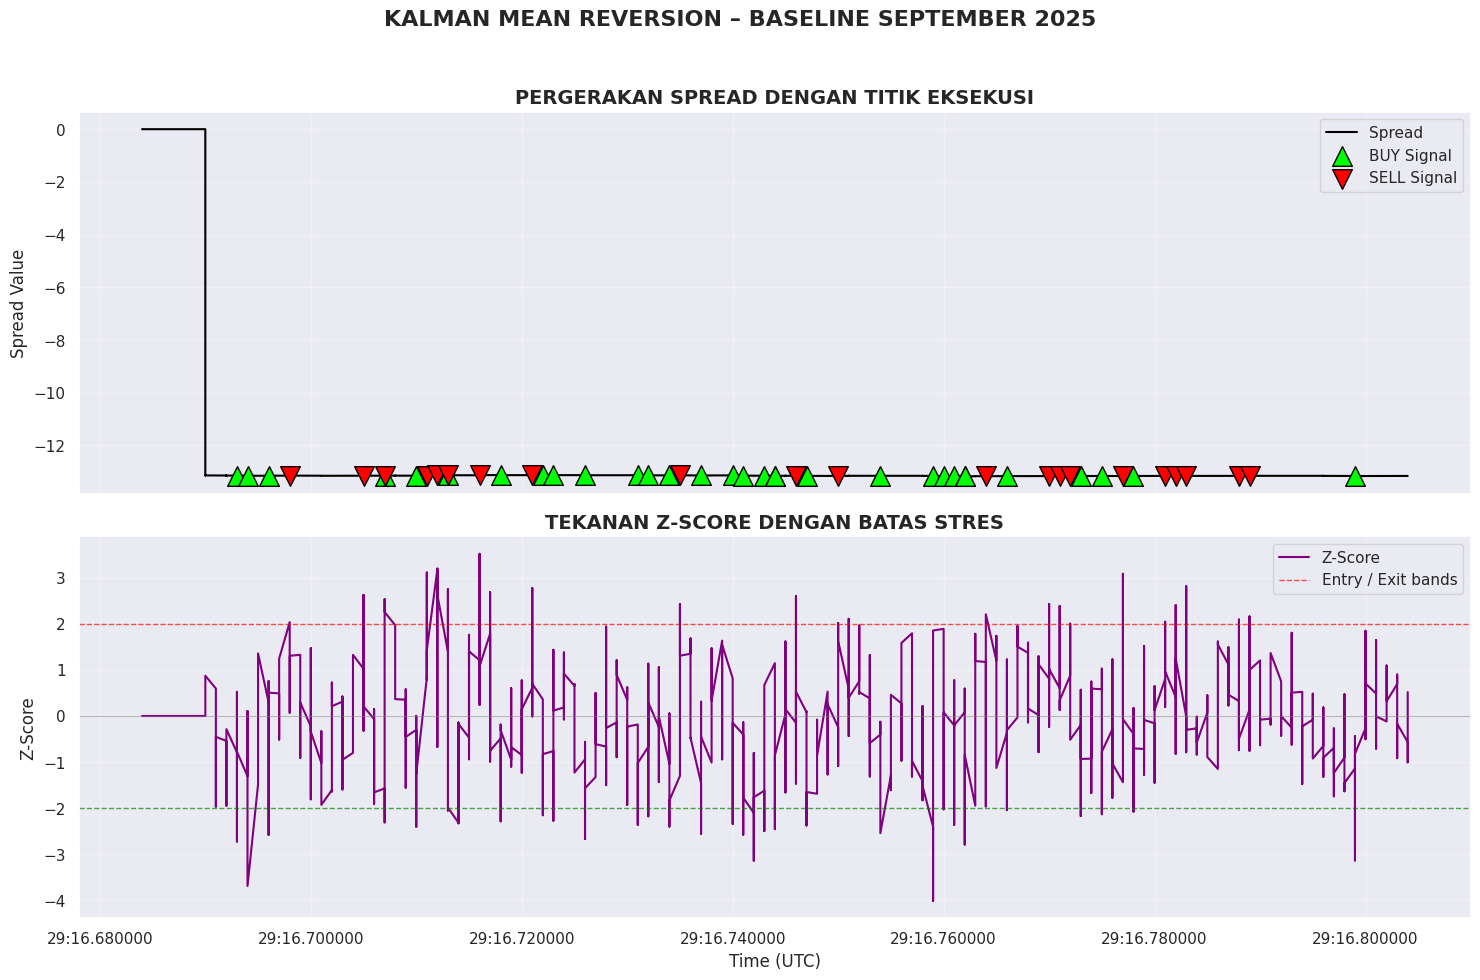

In [21]:
# CELL 4: Radar Visualization (The Dopamine Hit)

# 1. Prepare canvas & lens (zoom into first 2000 rows)
visualization_slice_dataframe: pd.DataFrame = clean_signal_dataframe.head(2000).copy()

# Convert timestamp from milliseconds to readable datetime for x‑axis
visualization_slice_dataframe['datetime'] = pd.to_datetime(
    visualization_slice_dataframe['timestamp'], unit='ms'
)

# 2. Build two‑level structure (subplots)
main_canvas, (top_spread_axis, bottom_zscore_axis) = plt.subplots(
    nrows=2, ncols=1,
    sharex=True,
    figsize=(15, 10)
)

# 3. Paint top level: spread & execution markers
top_spread_axis.plot(
    visualization_slice_dataframe['datetime'],
    visualization_slice_dataframe['spread_val'],
    color='black',
    linewidth=1.5,
    label='Spread'
)

# Filter buy (LONG) and sell (SHORT) signals
buy_signals = visualization_slice_dataframe[
    visualization_slice_dataframe['signal_type'] == 'BUY'
]
sell_signals = visualization_slice_dataframe[
    visualization_slice_dataframe['signal_type'] == 'SELL'
]

# Plot markers for buys (green triangles up) and sells (red triangles down)
top_spread_axis.scatter(
    buy_signals['datetime'],
    buy_signals['spread_val'],
    marker='^',
    color='lime',
    s=200,                # marker size (area)
    edgecolors='black',
    linewidth=1,
    label='BUY Signal',
    zorder=5
)

top_spread_axis.scatter(
    sell_signals['datetime'],
    sell_signals['spread_val'],
    marker='v',
    color='red',
    s=200,
    edgecolors='black',
    linewidth=1,
    label='SELL Signal',
    zorder=5
)

top_spread_axis.set_ylabel('Spread Value', fontsize=12)
top_spread_axis.set_title('PERGERAKAN SPREAD DENGAN TITIK EKSEKUSI', fontsize=14, fontweight='bold')
top_spread_axis.legend(loc='upper right')
top_spread_axis.grid(True, alpha=0.3)

# 4. Paint bottom level: Z‑score & stress thresholds
bottom_zscore_axis.plot(
    visualization_slice_dataframe['datetime'],
    visualization_slice_dataframe['z_score'],
    color='purple',
    linewidth=1.5,
    label='Z‑Score'
)

# Horizontal threshold lines
bottom_zscore_axis.axhline(
    y=2.0,
    color='red',
    linestyle='--',
    linewidth=1,
    alpha=0.7,
    label='Entry / Exit bands'
)
bottom_zscore_axis.axhline(
    y=-2.0,
    color='green',
    linestyle='--',
    linewidth=1,
    alpha=0.7
)
bottom_zscore_axis.axhline(
    y=0.0,
    color='gray',
    linestyle='-',
    linewidth=0.8,
    alpha=0.5
)

bottom_zscore_axis.set_ylabel('Z‑Score', fontsize=12)
bottom_zscore_axis.set_xlabel('Time (UTC)', fontsize=12)
bottom_zscore_axis.set_title('TEKANAN Z‑SCORE DENGAN BATAS STRES', fontsize=14, fontweight='bold')
bottom_zscore_axis.legend(loc='upper right')
bottom_zscore_axis.grid(True, alpha=0.3)

# 5. Final polish
plt.suptitle('KALMAN MEAN REVERSION – BASELINE SEPTEMBER 2025', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # make room for suptitle

# 6. Reveal the masterpiece
plt.savefig('/home/bumip/orca/research/notebook/plot_result/baseline_september_25', dpi=300, bbox_inches='tight')
plt.show()

🔍 KOMPREHENSIF SIGNAL STATISTICS – BASELINE KALMAN (SEPTEMBER 2025)

📊 TOTAL ROWS PROCESSED: 43,200

📈 SIGNAL TYPE DISTRIBUTION:
   NEUTRAL   : 40,710 (94.24%)
   EXIT      :  1,202 ( 2.78%)
   BUY       :    625 ( 1.45%)
   SELL      :    620 ( 1.44%)
   STOP      :     43 ( 0.10%)

   → ENTRY SIGNALS (BUY+SELL) :  1,245
   → EXIT SIGNALS (EXIT+STOP) :  1,245
   → NEUTRAL                  : 40,710

📐 DESCRIPTIVE STATISTICS:
              count     mean     std      min      25%      50%      75%     max
z_score     43200.0  -0.0094  1.1387 -10.1628  -0.7433  -0.0140   0.7181  5.4335
spread_val  43200.0 -13.0209  0.6285 -13.1798 -13.1041 -13.0604 -12.9843  0.0000
volatility  43200.0   0.0010  0.0001   0.0000   0.0010   0.0010   0.0010  0.0014
factor_q    43200.0   1.1794  0.4202   1.0000   1.0000   1.0000   1.1502  3.5000

🔥 Z-SCORE EXTREMES:  max = 5.433,  min = -10.163
⚙️  FACTOR Q (volatility modulation):  min = 1.000,  mean = 1.179,  max = 3.500


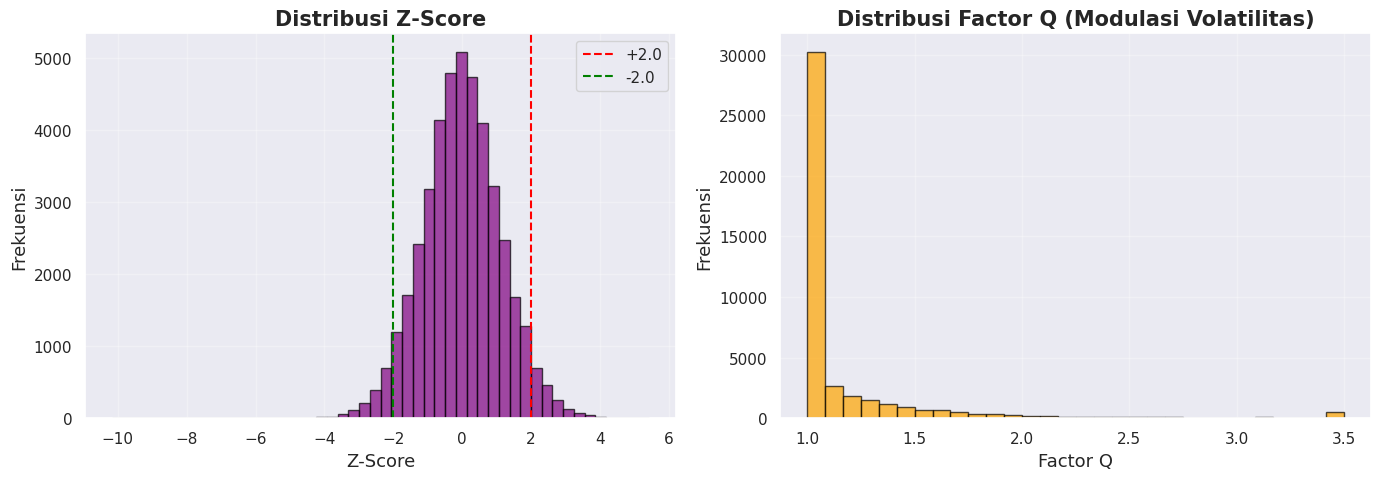


📋 SAMPLE SIGNALS (first 10 rows):
 timestamp                datetime signal_type  z_score  spread_val  factor_q
   1756684 1970-01-01 00:29:16.684     NEUTRAL      0.0         0.0       1.0
   1756684 1970-01-01 00:29:16.684     NEUTRAL      0.0         0.0       1.0
   1756684 1970-01-01 00:29:16.684     NEUTRAL      0.0         0.0       1.0
   1756684 1970-01-01 00:29:16.684     NEUTRAL      0.0         0.0       1.0
   1756685 1970-01-01 00:29:16.685     NEUTRAL      0.0         0.0       1.0
   1756685 1970-01-01 00:29:16.685     NEUTRAL      0.0         0.0       1.0
   1756685 1970-01-01 00:29:16.685     NEUTRAL      0.0         0.0       1.0
   1756685 1970-01-01 00:29:16.685     NEUTRAL      0.0         0.0       1.0
   1756685 1970-01-01 00:29:16.685     NEUTRAL      0.0         0.0       1.0
   1756685 1970-01-01 00:29:16.685     NEUTRAL      0.0         0.0       1.0

✅ Diagnostic summary complete.


In [22]:
# CELL 5: Comprehensive Signal Statistics & Diagnostic Summary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure we are working with the full clean signal dataframe
signal_df = clean_signal_dataframe.copy()

# 2. Add readable datetime column (convert from milliseconds)
signal_df['datetime'] = pd.to_datetime(signal_df['timestamp'], unit='ms')

# 3. Count signal types
signal_counts = signal_df['signal_type'].value_counts()
total_signals = len(signal_df)

# 4. Separate entry and exit signals
entry_signals = signal_df[signal_df['signal_type'].isin(['BUY', 'SELL'])]
exit_signals = signal_df[signal_df['signal_type'].isin(['EXIT', 'STOP'])]
neutral_signals = signal_df[signal_df['signal_type'] == 'NEUTRAL']

# 5. Print detailed summary
print("=" * 80)
print("🔍 KOMPREHENSIF SIGNAL STATISTICS – BASELINE KALMAN (SEPTEMBER 2025)")
print("=" * 80)

print(f"\n📊 TOTAL ROWS PROCESSED: {total_signals:,}")
print(f"\n📈 SIGNAL TYPE DISTRIBUTION:")
for sig_type, count in signal_counts.items():
    percentage = (count / total_signals) * 100
    print(f"   {sig_type:10}: {count:6,} ({percentage:5.2f}%)")

print(f"\n   → ENTRY SIGNALS (BUY+SELL) : {len(entry_signals):6,}")
print(f"   → EXIT SIGNALS (EXIT+STOP) : {len(exit_signals):6,}")
print(f"   → NEUTRAL                  : {len(neutral_signals):6,}")

# 6. Basic statistics for key columns
print("\n📐 DESCRIPTIVE STATISTICS:")
stats_cols = ['z_score', 'spread_val', 'volatility', 'factor_q']
stats_df = signal_df[stats_cols].describe().T
stats_df = stats_df.round(4)
print(stats_df.to_string())

# 7. Additional diagnostics: maximum absolute z-score, etc.
max_z = signal_df['z_score'].max()
min_z = signal_df['z_score'].min()
print(f"\n🔥 Z-SCORE EXTREMES:  max = {max_z:.3f},  min = {min_z:.3f}")

# 8. Factor Q range (volatility modulation)
q_min = signal_df['factor_q'].min()
q_max = signal_df['factor_q'].max()
q_mean = signal_df['factor_q'].mean()
print(f"⚙️  FACTOR Q (volatility modulation):  min = {q_min:.3f},  mean = {q_mean:.3f},  max = {q_max:.3f}")

# 9. Visual summary: histogram of z-scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of z-scores
axes[0].hist(signal_df['z_score'], bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0].axvline(x=2.0, color='red', linestyle='--', linewidth=1.5, label='+2.0')
axes[0].axvline(x=-2.0, color='green', linestyle='--', linewidth=1.5, label='-2.0')
axes[0].set_title('Distribusi Z‑Score', fontweight='bold')
axes[0].set_xlabel('Z‑Score')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histogram of factor Q
axes[1].hist(signal_df['factor_q'], bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribusi Factor Q (Modulasi Volatilitas)', fontweight='bold')
axes[1].set_xlabel('Factor Q')
axes[1].set_ylabel('Frekuensi')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/home/bumip/orca/research/notebook/plot_result/det_baseline_september_25', dpi=300, bbox_inches='tight')
plt.show()

# 10. Sample signals (first 10 rows) – now with datetime column
print("\n📋 SAMPLE SIGNALS (first 10 rows):")
sample_columns = ['timestamp', 'datetime', 'signal_type', 'z_score', 'spread_val', 'factor_q']
print(signal_df[sample_columns].head(10).to_string(index=False))

print("\n✅ Diagnostic summary complete.")